In [1]:
# !pip install pandas numpy matplotlib seaborn

### Data cleansing

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
def wrangle(path, col_1, col_2):

    # Import data
    df = pd.read_csv(path)

    # Datetime 
    df[col_1] = pd.to_datetime(df[col_1])

    # Rename the column to date
    df.rename(columns={col_1: 'Date'}, inplace=True)

    # Replace missing values
    df[col_2] = df[col_2].replace('.', pd.NA)
    # Convert to numeric, coercing errors to NaN
    df[col_2] = pd.to_numeric(df[col_2], errors='coerce')

    # Only select data after 2000
    df = df[df['Date'] >= '2000-01-01']

    df = df.set_index('Date')

    # Create a full date range from 2000-01-01 to 2024-11-20
    full_date_range = pd.date_range(start='2000-01-01', end='2024-11-20', freq='D')

    # Reindex the DataFrame with the full date range
    df = df.reindex(full_date_range)
    df.index.name = 'Date' # Change the index name back to "Date"

    # # Forward fill missing values
    # df = df.ffill()

    return df

In [4]:
vix = wrangle("/Users/alexzheng/Developer/GitHub/Forecasting-Yen-Carry-Trade-Risk-Using-an-LLM/data/CBOE_Volatility_Index.csv",
        "DATE",
        "VIXCLS")
vix

,VIXCLS
Date,
2000-01-01,NaN
2000-01-02,NaN
2000-01-03,24.21
2000-01-04,27.01
2000-01-05,26.41
...,...
2024-11-16,NaN
2024-11-17,NaN
2024-11-18,15.58


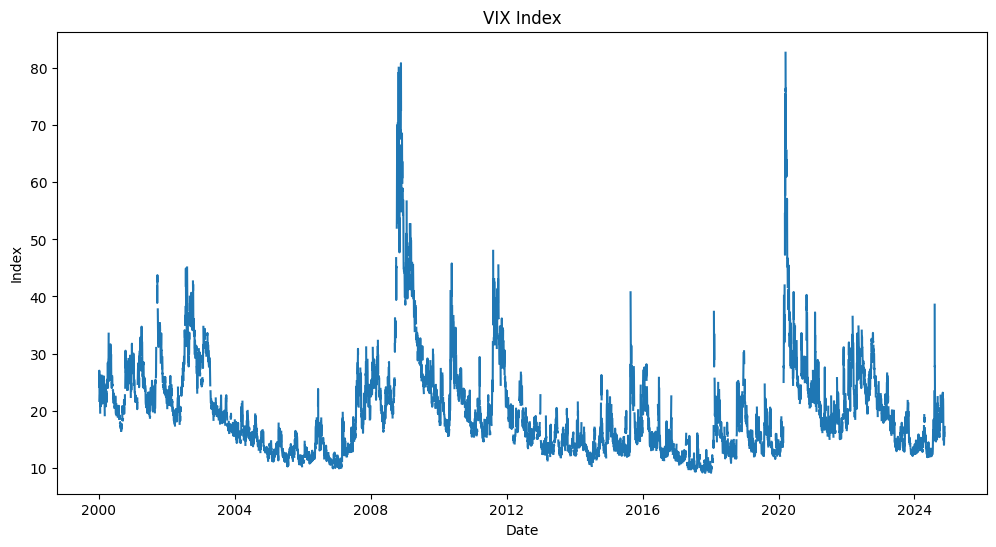

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(vix.index, vix['VIXCLS'])
plt.xlabel('Date')
plt.ylabel('Index')
plt.title("VIX Index");

In [6]:
JPY_exchange_rate_per_USD = wrangle("/Users/alexzheng/Developer/GitHub/Forecasting-Yen-Carry-Trade-Risk-Using-an-LLM/data/Japanese_Yen_to_US_Dollar_Spot_Exchange_Rate.csv",
                                    "DATE",
                                    "DEXJPUS")
JPY_exchange_rate_per_USD

,DEXJPUS
Date,
2000-01-01,NaN
2000-01-02,NaN
2000-01-03,101.70
2000-01-04,103.09
2000-01-05,103.77
...,...
2024-11-16,NaN
2024-11-17,NaN
2024-11-18,NaN


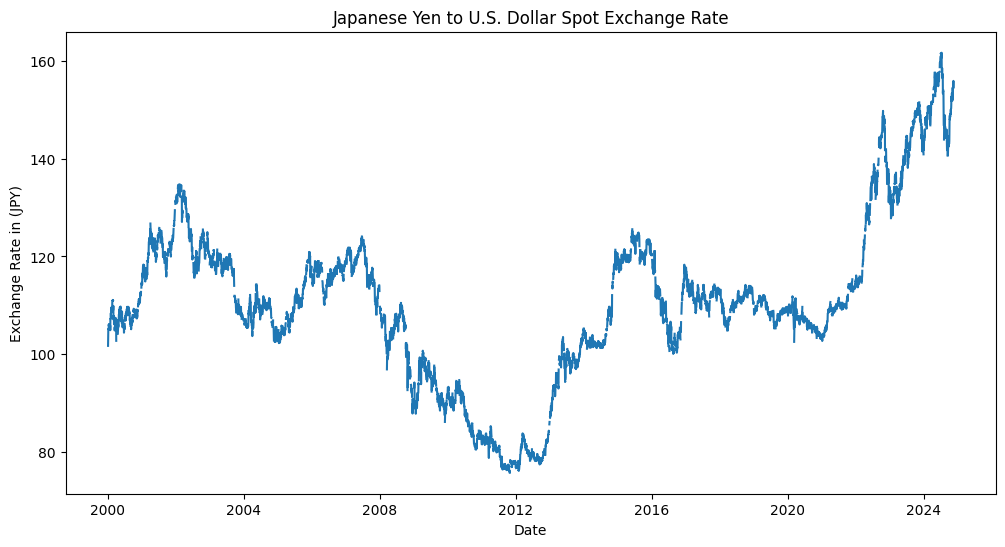

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(JPY_exchange_rate_per_USD.index, JPY_exchange_rate_per_USD['DEXJPUS'])
plt.xlabel('Date')
plt.ylabel('Exchange Rate in (JPY)')
plt.title("Japanese Yen to U.S. Dollar Spot Exchange Rate");

In [8]:
Japan_IR = wrangle("/Users/alexzheng/Developer/GitHub/Forecasting-Yen-Carry-Trade-Risk-Using-an-LLM/data/Japan_Government_Debt_10_Year.csv",
                                        "Pricing Date",
                                        "Japan Government Debt - 10 Year")

Japan_IR

,Japan Government Debt - 10 Year
Date,
2000-01-01,1.600
2000-01-02,1.600
2000-01-03,1.600
2000-01-04,1.660
2000-01-05,1.640
...,...
2024-11-16,NaN
2024-11-17,NaN
2024-11-18,1.065


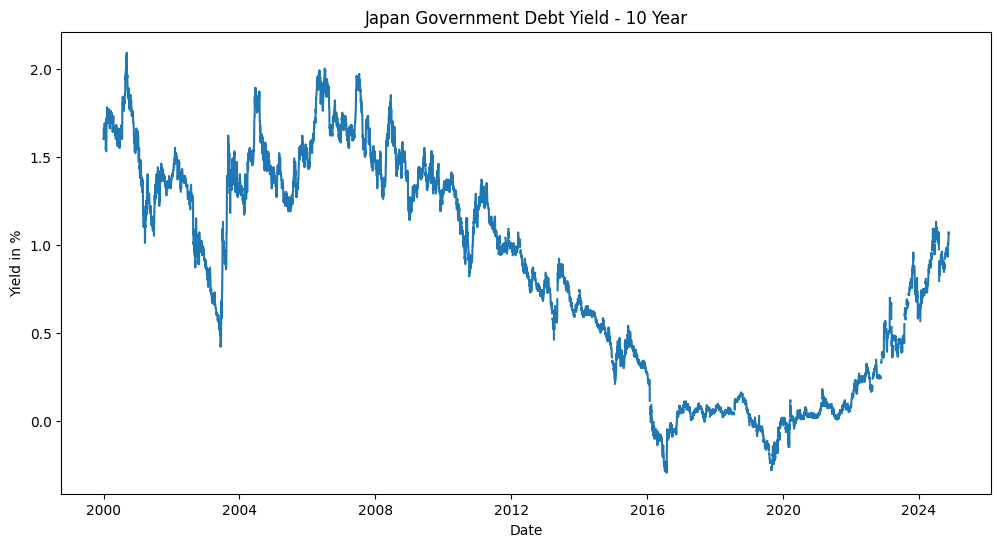

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(Japan_IR.index, Japan_IR['Japan Government Debt - 10 Year'])
plt.xlabel('Date')
plt.ylabel('Yield in %')
plt.title("Japan Government Debt Yield - 10 Year");

In [10]:
US_IR = wrangle("/Users/alexzheng/Developer/GitHub/Forecasting-Yen-Carry-Trade-Risk-Using-an-LLM/data/Market_Yield_US_Treasury_Securities_10_Year_Constant_Maturity_Investment_Basis.csv",
                "DATE",
                "DGS10")
US_IR

,DGS10
Date,
2000-01-01,NaN
2000-01-02,NaN
2000-01-03,6.58
2000-01-04,6.49
2000-01-05,6.62
...,...
2024-11-16,NaN
2024-11-17,NaN
2024-11-18,4.42


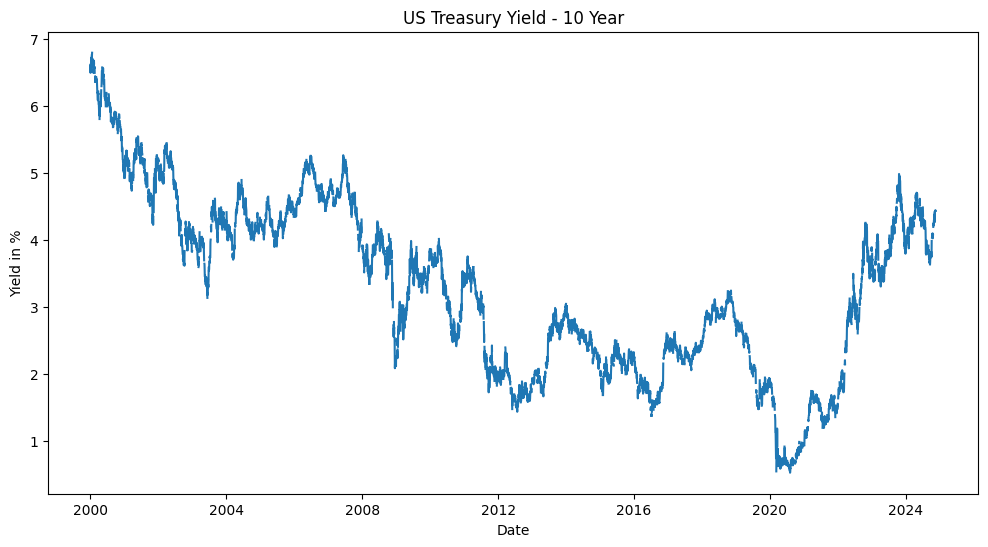

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(US_IR.index, US_IR['DGS10'])
plt.xlabel('Date')
plt.ylabel('Yield in %')
plt.title("US Treasury Yield - 10 Year");

#### Combining the four data frames

In [12]:

# Renaming columns 
vix.rename(columns={"VIXCLS": "VIX_Index"}, inplace=True)
JPY_exchange_rate_per_USD.rename(columns={"DEXJPUS": "JPY_USD_Exchange_Rate"}, inplace=True)
Japan_IR.rename(columns={"Japan Government Debt - 10 Year": "Japan_10Y_IR"}, inplace=True)
US_IR.rename(columns={"DGS10": "US_10Y_IR"}, inplace=True)

# Performing outer joins to keep all data
combined_df = pd.merge(vix, JPY_exchange_rate_per_USD, on='Date', how='outer')
combined_df = pd.merge(combined_df, Japan_IR, on='Date', how='outer')
combined_df = pd.merge(combined_df, US_IR, on='Date', how='outer')

# Sorting by date for a cleaner view
combined_df.sort_index(inplace=True)

# Displaying the final dataframe and saving it
print(combined_df.head(10)) 
print(combined_df.tail(10)) 
combined_df.to_csv("/Users/alexzheng/Developer/GitHub/Forecasting-Yen-Carry-Trade-Risk-Using-an-LLM/data/combined_data_full.csv", index=True)

            VIX_Index  JPY_USD_Exchange_Rate  Japan_10Y_IR  US_10Y_IR
Date                                                                 
2000-01-01        NaN                    NaN          1.60        NaN
2000-01-02        NaN                    NaN          1.60        NaN
2000-01-03      24.21                 101.70          1.60       6.58
2000-01-04      27.01                 103.09          1.66       6.49
2000-01-05      26.41                 103.77          1.64       6.62
2000-01-06      25.73                 105.19          1.62       6.57
2000-01-07      21.72                 105.17          1.65       6.52
2000-01-08        NaN                    NaN          1.65        NaN
2000-01-09        NaN                    NaN          1.65        NaN
2000-01-10      21.71                 105.28          1.65       6.57
            VIX_Index  JPY_USD_Exchange_Rate  Japan_10Y_IR  US_10Y_IR
Date                                                                 
2024-11-11      14.9

In [13]:
# Count non-NaN values in each column
combined_df.count()

VIX_Index                6281
JPY_USD_Exchange_Rate    6238
Japan_10Y_IR             7807
US_10Y_IR                6224
dtype: int64

In [14]:
# Count NaN values in each column
combined_df.isna().sum()

VIX_Index                2810
JPY_USD_Exchange_Rate    2853
Japan_10Y_IR             1284
US_10Y_IR                2867
dtype: int64

In [15]:
# Forward fill missing values
cleaned_df = combined_df.ffill() 
cleaned_df.dropna(inplace=True)

In [16]:
# Count NaN values in each column
cleaned_df.isna().sum()

VIX_Index                0
JPY_USD_Exchange_Rate    0
Japan_10Y_IR             0
US_10Y_IR                0
dtype: int64

In [17]:
cleaned_df.head(10)

,VIX_Index,JPY_USD_Exchange_Rate,Japan_10Y_IR,US_10Y_IR
Date,,,,
2000-01-03,24.21,101.70,1.60,6.58
2000-01-04,27.01,103.09,1.66,6.49
2000-01-05,26.41,103.77,1.64,6.62
2000-01-06,25.73,105.19,1.62,6.57
2000-01-07,21.72,105.17,1.65,6.52
2000-01-08,21.72,105.17,1.65,6.52
2000-01-09,21.72,105.17,1.65,6.52
2000-01-10,21.71,105.28,1.65,6.57
2000-01-11,22.50,106.09,1.65,6.67


In [18]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9089 entries, 2000-01-03 to 2024-11-20
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VIX_Index              9089 non-null   float64
 1   JPY_USD_Exchange_Rate  9089 non-null   float64
 2   Japan_10Y_IR           9089 non-null   float64
 3   US_10Y_IR              9089 non-null   float64
dtypes: float64(4)
memory usage: 355.0 KB


In [19]:
cleaned_df.describe()

,VIX_Index,JPY_USD_Exchange_Rate,Japan_10Y_IR,US_10Y_IR
count,9089.000000,9089.000000,9089.000000,9089.000000
mean,19.812832,110.684957,0.835593,3.277632
std,8.443347,16.551183,0.617181,1.304853
min,9.140000,75.720000,-0.295000,0.520000
25%,13.790000,103.190000,0.220000,2.200000
50%,17.770000,109.940000,0.870000,3.290000
75%,23.330000,118.840000,1.380000,4.270000
max,82.690000,161.730000,2.090000,6.790000


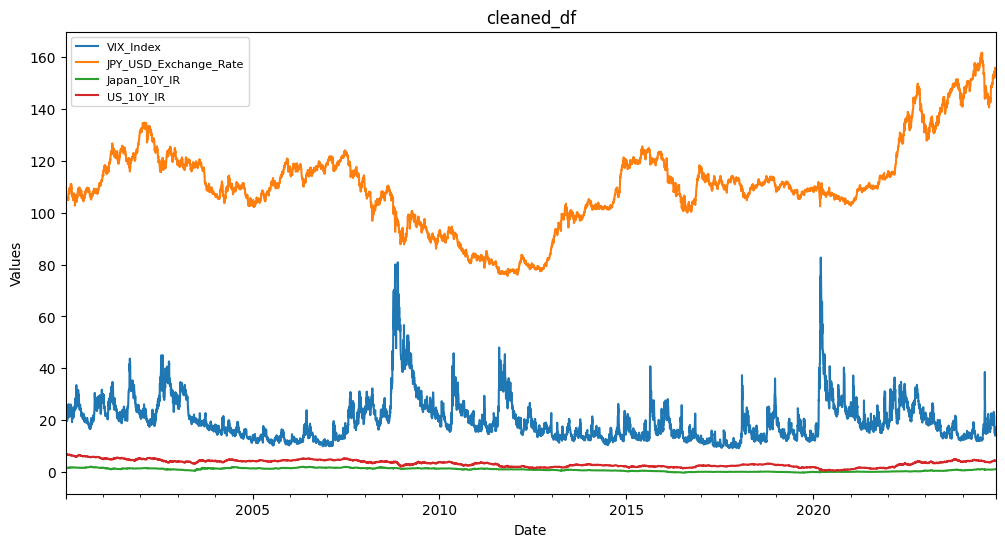

In [20]:
cleaned_df.plot(figsize=(12, 6), title="cleaned_df")
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend(loc='upper left', prop={'size': 8});

### Compute carry trade returns

In [21]:
# Convert Japan and US interest rates into decimals 
cleaned_df = cleaned_df.copy()

cleaned_df['US_10Y_IR'] = cleaned_df['US_10Y_IR'] / 100
cleaned_df['Japan_10Y_IR'] = cleaned_df['Japan_10Y_IR'] / 100

In [22]:
cleaned_df.head(10)

,VIX_Index,JPY_USD_Exchange_Rate,Japan_10Y_IR,US_10Y_IR
Date,,,,
2000-01-03,24.21,101.70,0.0160,0.0658
2000-01-04,27.01,103.09,0.0166,0.0649
2000-01-05,26.41,103.77,0.0164,0.0662
2000-01-06,25.73,105.19,0.0162,0.0657
2000-01-07,21.72,105.17,0.0165,0.0652
2000-01-08,21.72,105.17,0.0165,0.0652
2000-01-09,21.72,105.17,0.0165,0.0652
2000-01-10,21.71,105.28,0.0165,0.0657
2000-01-11,22.50,106.09,0.0165,0.0667


### Compute carry trade returns

In [23]:
# Convert US and Japan 10Y bond yields to daily rates
cleaned_df['US_10Y_IR_daily'] = ((1 + cleaned_df['US_10Y_IR']) ** (1/252)) - 1
cleaned_df['Japan_10Y_IR_daily'] = ((1 + cleaned_df['Japan_10Y_IR']) ** (1/252)) - 1

In [24]:
# Create shifted interest rates and exchange rates to represent t-1
cleaned_df['US_10Y_IR_daily_t-1'] = cleaned_df['US_10Y_IR_daily'].shift(1)
cleaned_df['Japan_10Y_IR_daily_t-1'] = cleaned_df['Japan_10Y_IR_daily'].shift(1)
cleaned_df['Exchange_Rate_t-1'] = cleaned_df['JPY_USD_Exchange_Rate'].shift(1)

# Carry trade returns
cleaned_df['carry_trade_returns'] = (1 + cleaned_df['US_10Y_IR_daily_t-1']) * (cleaned_df['JPY_USD_Exchange_Rate'] / cleaned_df['Exchange_Rate_t-1']) - (1 + cleaned_df['Japan_10Y_IR_daily_t-1'])

# Drop rows with NaN values caused by shifting
cleaned_df.dropna(inplace=True)

In [25]:
cleaned_df

,VIX_Index,JPY_USD_Exchange_Rate,Japan_10Y_IR,US_10Y_IR,US_10Y_IR_daily,Japan_10Y_IR_daily,US_10Y_IR_daily_t-1,Japan_10Y_IR_daily_t-1,Exchange_Rate_t-1,carry_trade_returns
Date,,,,,,,,,,
2000-01-04,27.01,103.09,0.01660,0.0649,0.000250,0.000065,0.000253,0.000063,101.70,0.013861
2000-01-05,26.41,103.77,0.01640,0.0662,0.000254,0.000065,0.000250,0.000065,103.09,0.006782
2000-01-06,25.73,105.19,0.01620,0.0657,0.000253,0.000064,0.000254,0.000065,103.77,0.013877
2000-01-07,21.72,105.17,0.01650,0.0652,0.000251,0.000065,0.000253,0.000064,105.19,-0.000001
2000-01-08,21.72,105.17,0.01650,0.0652,0.000251,0.000065,0.000251,0.000065,105.17,0.000186
...,...,...,...,...,...,...,...,...,...,...
2024-11-16,16.14,154.59,0.01070,0.0443,0.000172,0.000042,0.000172,0.000042,154.59,0.000130
2024-11-17,16.14,154.59,0.01070,0.0443,0.000172,0.000042,0.000172,0.000042,154.59,0.000130
2024-11-18,15.58,154.59,0.01065,0.0442,0.000172,0.000042,0.000172,0.000042,154.59,0.000130


In [26]:
cleaned_df.describe()

,VIX_Index,JPY_USD_Exchange_Rate,Japan_10Y_IR,US_10Y_IR,US_10Y_IR_daily,Japan_10Y_IR_daily,US_10Y_IR_daily_t-1,Japan_10Y_IR_daily_t-1,Exchange_Rate_t-1,carry_trade_returns
count,9088.000000,9088.000000,9088.000000,9088.000000,9088.000000,9088.000000,9088.000000,9088.000000,9088.000000,9088.000000
mean,19.812348,110.685945,0.008355,0.032773,0.000128,0.000033,0.000128,0.000033,110.680125,0.000154
std,8.443685,16.551825,0.006172,0.013045,0.000050,0.000024,0.000050,0.000024,16.545683,0.005150
min,9.140000,75.720000,-0.002950,0.005200,0.000021,-0.000012,0.000021,-0.000012,75.720000,-0.050744
25%,13.790000,103.190000,0.002200,0.022000,0.000086,0.000009,0.000086,0.000009,103.190000,-0.001296
50%,17.770000,109.940000,0.008700,0.032900,0.000128,0.000034,0.000128,0.000034,109.940000,0.000098
75%,23.315000,118.842500,0.013725,0.042700,0.000166,0.000054,0.000166,0.000054,118.840000,0.001813
max,82.690000,161.730000,0.020900,0.067900,0.000261,0.000082,0.000261,0.000082,161.730000,0.034045


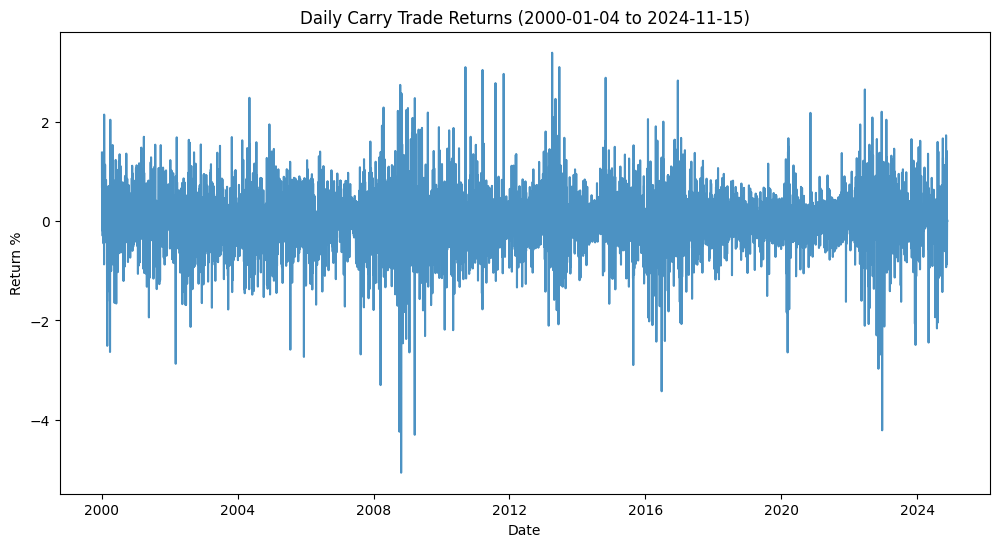

In [27]:
plt.figure(figsize=(12, 6))
plt.plot(cleaned_df.index, cleaned_df['carry_trade_returns']*100, label='Daily Carry Trade Returns', alpha=0.8)
plt.title("Daily Carry Trade Returns (2000-01-04 to 2024-11-15)")
plt.xlabel("Date")
plt.ylabel("Return %");

In [28]:
# Save the full dataset 
cleaned_df.to_csv("/Users/alexzheng/Developer/GitHub/Forecasting-Yen-Carry-Trade-Risk-Using-an-LLM/data/cleaned_data_full.csv", index=True)

In [29]:
# Save the return dataset
cleaned_df['carry_trade_returns'].to_csv("/Users/alexzheng/Developer/GitHub/Forecasting-Yen-Carry-Trade-Risk-Using-an-LLM/data/returns.csv", index=True)